# Parkinson's Disease - Model Building

# 1. Imports & Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import roc_curve, auc

import sys
sys.path.append(".")
from utlis import (evaluate_model, plot_confusion_matrix,
                   cross_validate_model, compare_models)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

%matplotlib inline

In [2]:
df = pd.read_csv("parkinsons_cleaned.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (195, 27)


,Fo_Hz,Fhi_Hz,Flo_Hz,Jitter_pct,Jitter_Abs,RAP,PPQ,Jitter_DDP,Shimmer,Shimmer_dB,...,RPDE,DFA,spread1,spread2,D2,PPE,frequency_range,jitter_avg,shimmer_avg,voice_to_noise
0,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,0.426,...,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654,82.305,0.005648,0.117662,951.288966
1,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,0.626,...,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674,34.831,0.007062,0.171578,989.372681
2,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,0.482,...,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634,19.556,0.008034,0.136636,1577.616381
3,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,0.517,...,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975,26.505,0.007422,0.145784,1525.794418
4,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,0.584,...,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335,31.126,0.009648,0.167220,1111.997673


# 2. Train / Test Split + Scaling

In [3]:
X = df.drop(columns = ["status"])
y = df["status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify = y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train PD rate : {y_train.mean(): .3f}, Test PD rate : {y_test.mean():.3f}")

Train: (156, 26), Test: (39, 26)
Train PD rate :  0.756, Test PD rate : 0.744


# 3. Model 1 - Logistic Regression


Logistic Regression
Accuracy    : 0.7692
Precision   : 0.9545
Recall      : 0.7241
F1 Score    : 0.8235


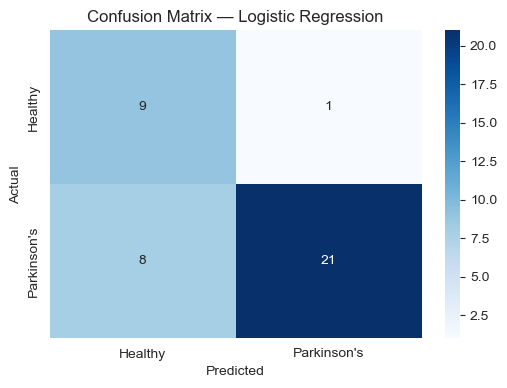

In [4]:
lr = LogisticRegression(max_iter = 2000, random_state = 42, class_weight = "balanced")
lr.fit(X_train_s, y_train)
pred_lr = lr.predict(X_test_s)
m_lr = evaluate_model("Logistic Regression", y_test, pred_lr)
plot_confusion_matrix(y_test, pred_lr, "Logistic Regression");
plt.show()

# 4. Model 2 - Decision Tree


Decision Tree
Accuracy    : 0.8462
Precision   : 0.9600
Recall      : 0.8276
F1 Score    : 0.8889


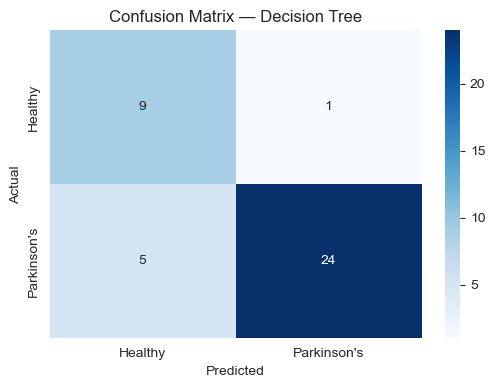

In [5]:
dt = DecisionTreeClassifier(random_state = 42, class_weight = "balanced")
dt.fit(X_train, y_train)
pred_dt = dt.predict(X_test)
m_dt = evaluate_model("Decision Tree", y_test, pred_dt)
plot_confusion_matrix(y_test, pred_dt, "Decision Tree");
plt.show()

# 5. Model 3 - Random Forest


Random Forest
Accuracy    : 0.8974
Precision   : 0.9310
Recall      : 0.9310
F1 Score    : 0.9310


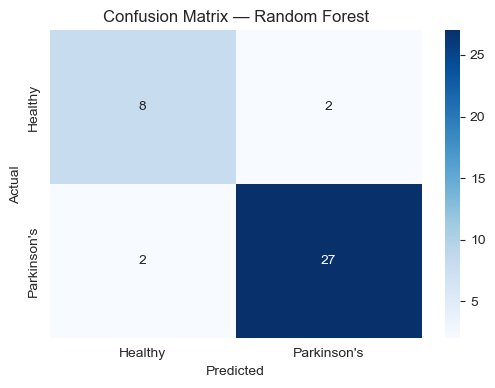

In [6]:
rf = RandomForestClassifier(n_estimators = 300, random_state = 42, class_weight = "balanced")
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
m_rf = evaluate_model("Random Forest", y_test, pred_rf)
plot_confusion_matrix(y_test, pred_rf, "Random Forest"); 
plt.show()

# 6. Model 4 - KNN (with K optimization)

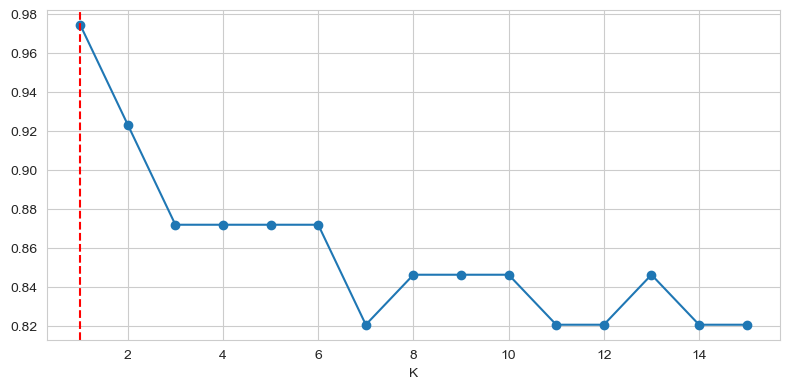


KNN (K = 1)
Accuracy    : 0.9744
Precision   : 0.9667
Recall      : 1.0000
F1 Score    : 0.9831


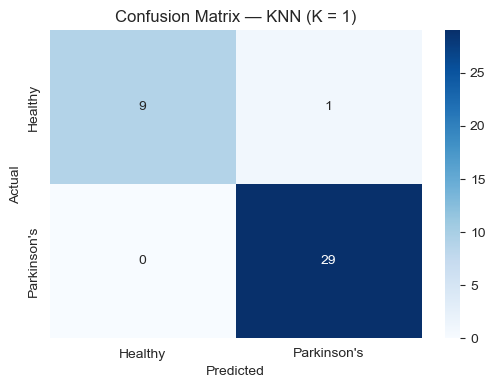

In [7]:
ks = list(range(1,16))
acc = []
for k in ks:
    kk = KNeighborsClassifier(n_neighbors = k)
    kk.fit(X_train_s, y_train)
    acc.append(kk.score(X_test_s, y_test))

best_k = ks[int(np.argmax(acc))]
plt.figure(figsize = (8,4))
plt.plot(ks, acc, marker = "o")
plt.axvline(best_k, color = "red", linestyle = "--", label = f"Best K = {best_k}")
plt.xlabel("K"); plt.tight_layout(); plt.show()

knn = KNeighborsClassifier(n_neighbors = best_k)
knn.fit(X_train_s, y_train)
pred_knn = knn.predict(X_test_s)
m_knn = evaluate_model(f"KNN (K = {best_k})", y_test, pred_knn)
plot_confusion_matrix(y_test, pred_knn, f"KNN (K = {best_k})"); plt.show()

# 7. Model 5 - SVM


SVM
Accuracy    : 0.7949
Precision   : 1.0000
Recall      : 0.7241
F1 Score    : 0.8400


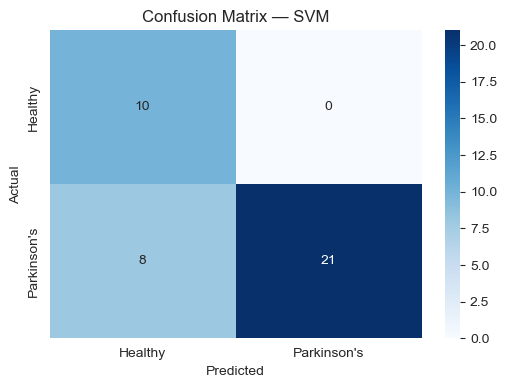

In [8]:
svm = SVC(kernel = "rbf", probability = True, class_weight = "balanced", random_state = 42)
svm.fit(X_train_s, y_train)
pred_svm = svm.predict(X_test_s)
m_svm = evaluate_model("SVM", y_test, pred_svm)
plot_confusion_matrix(y_test, pred_svm, "SVM");
plt.show()

# 8. Model 6 - Gradient Boosting


Gradient Boosting
Accuracy    : 0.8974
Precision   : 0.9310
Recall      : 0.9310
F1 Score    : 0.9310


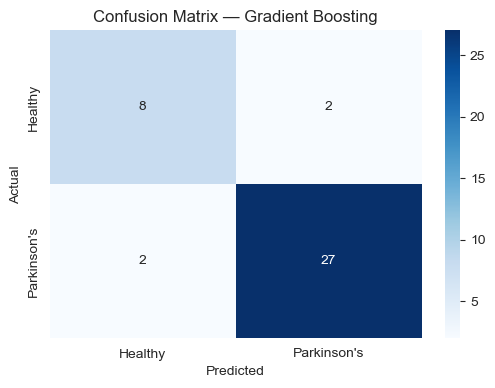

In [9]:
gb = GradientBoostingClassifier(random_state = 42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)
m_gb = evaluate_model("Gradient Boosting", y_test, pred_gb)
plot_confusion_matrix(y_test, pred_gb, "Gradient Boosting"); 
plt.show()

# 9. Model 7 - Naive Bayes


Naive Bayes
Accuracy    : 0.7179
Precision   : 0.8462
Recall      : 0.7586
F1 Score    : 0.8000


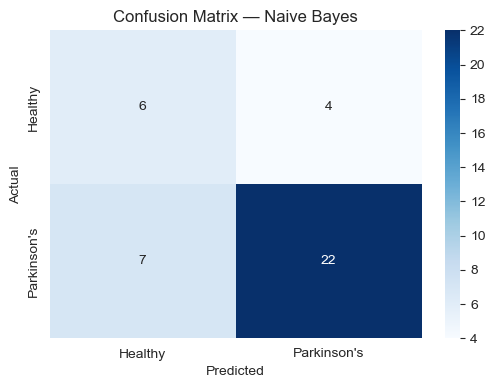

In [10]:
nb = GaussianNB()
nb.fit(X_train, y_train)
pred_nb = nb.predict(X_test)
m_nb = evaluate_model("Naive Bayes", y_test, pred_nb)
plot_confusion_matrix(y_test, pred_nb, "Naive Bayes"); 
plt.show()

# 10. Feature Importance (tree-based)

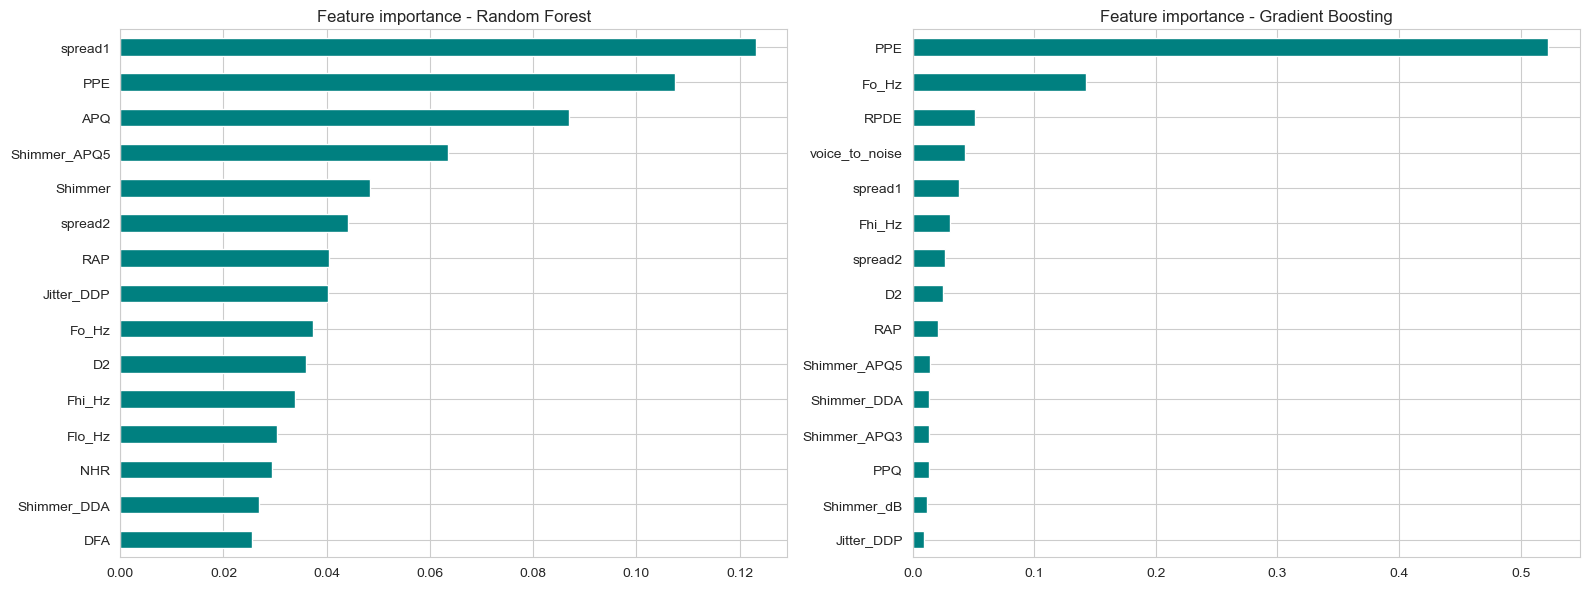

In [11]:
fig, axes = plt.subplots(1, 2, figsize = (16, 6))
for ax, model, name in [(axes[0], rf, "Random Forest"), (axes[1], gb, "Gradient Boosting")]:
    imp = pd.Series(model.feature_importances_, index = X.columns).sort_values()
    imp.tail(15).plot(kind = "barh", ax = ax, color = "teal")
    ax.set_title(f"Feature importance - {name}")
plt.tight_layout(); 
plt.show()

# 11. Model Comparison

In [12]:
results = [m_lr, m_dt, m_rf, m_knn, m_svm, m_gb, m_nb]
df_results = compare_models(results)
df_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score
0,KNN (K = 1),0.9744,0.9667,1.0000,0.9831
1,Gradient Boosting,0.8974,0.9310,0.9310,0.9310
2,Random Forest,0.8974,0.9310,0.9310,0.9310
3,Decision Tree,0.8462,0.9600,0.8276,0.8889
4,SVM,0.7949,1.0000,0.7241,0.8400
5,Logistic Regression,0.7692,0.9545,0.7241,0.8235
6,Naive Bayes,0.7179,0.8462,0.7586,0.8000


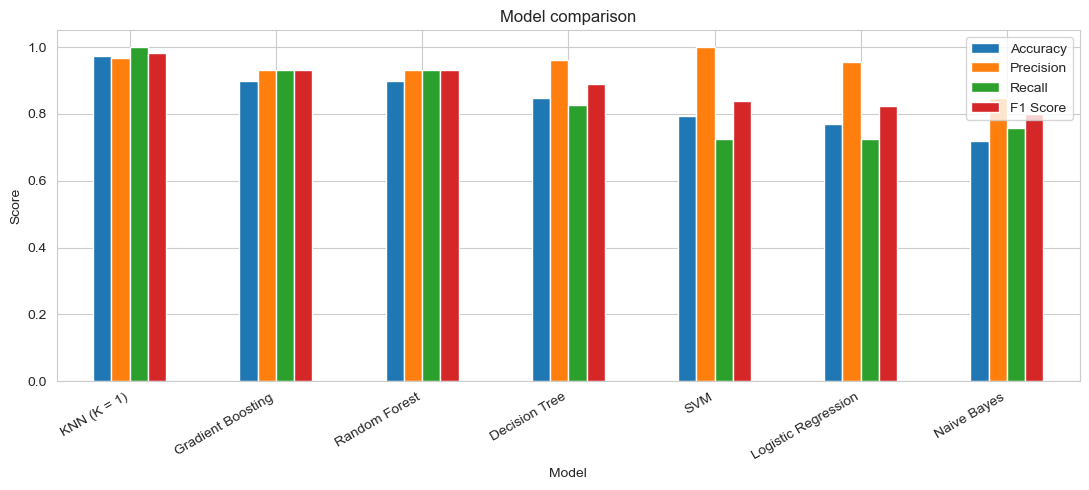

In [13]:
fig, ax = plt.subplots(figsize = (11, 5))
df_results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score"]].plot(kind = "bar", ax = ax)
ax.set_title("Model comparison")
ax.set_ylabel("Score")
plt.xticks(rotation = 30, ha = "right"); 
plt.tight_layout();
plt.show()

# 12. 5 - Fold Cross-Validation 

In [14]:
cv_models = {
    "Logistic Regression": (lr, X_train_s),
    "Decision Tree"      : (dt, X_train_s),
    "Random Forest"      : (rf, X_train_s),
    f"KNN (K = {best_k})": (knn, X_train_s),
    "SVM"                : (svm, X_train_s),
    "Gradient Boosting"  : (gb, X_train_s),
    "Naive Bayes"        : (nb, X_train_s)
}
cv_scores = {}
for name, (m, X_in) in cv_models.items():
    print(f"\n{name}")
    cv_scores[name] = cross_validate_model(m, X_in, y_train, cv = 5)


Logistic Regression
CV F1 Scores : [0.7907 0.913  0.8182 0.8444 0.8837]
Mean F1      : 0.8500 (+/- 0.0440)

Decision Tree
CV F1 Scores : [0.8936 0.9565 0.875  0.9167 0.8936]
Mean F1      : 0.9071 (+/- 0.0280)

Random Forest
CV F1 Scores : [0.8444 0.9362 0.898  0.9167 0.96  ]
Mean F1      : 0.9110 (+/- 0.0392)

KNN (K = 1)
CV F1 Scores : [0.9362 0.9778 0.9388 0.9787 0.9167]
Mean F1      : 0.9496 (+/- 0.0246)

SVM
CV F1 Scores : [0.8636 0.9048 0.7907 0.8889 0.8293]
Mean F1      : 0.8555 (+/- 0.0412)

Gradient Boosting
CV F1 Scores : [0.8936 0.9787 0.9167 0.96   0.9583]
Mean F1      : 0.9415 (+/- 0.0314)

Naive Bayes
CV F1 Scores : [0.8    0.85   0.7619 0.6486 0.7368]
Mean F1      : 0.7595 (+/- 0.0673)


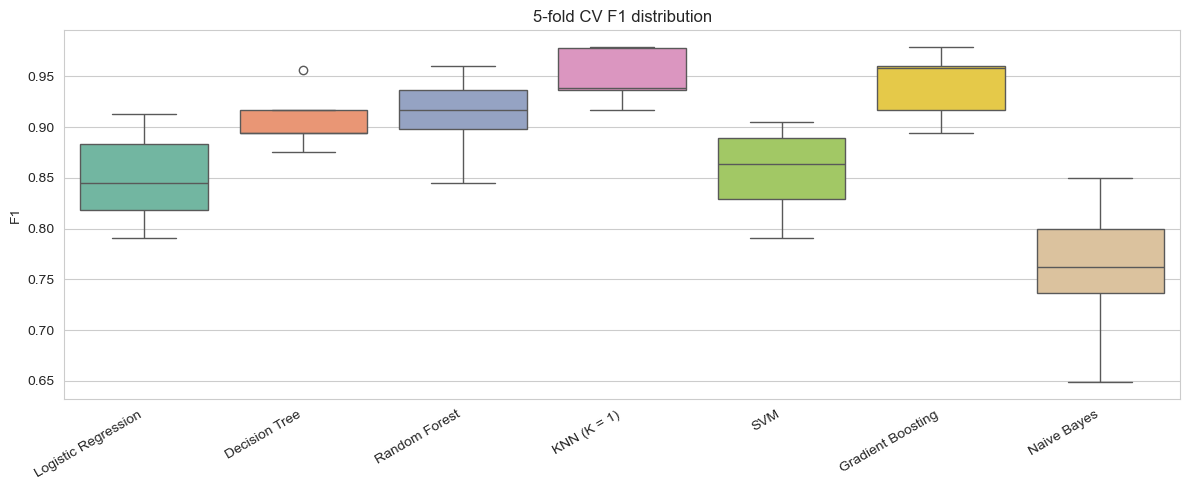

In [15]:
cv_df = pd.DataFrame(cv_scores)
plt.figure(figsize = (12, 5))
sns.boxplot(data = cv_df, palette = "Set2")
plt.title("5-fold CV F1 distribution")
plt.xticks(rotation = 30, ha = "right");
plt.ylabel("F1")
plt.tight_layout();
plt.show()

# 13. ROC Curves

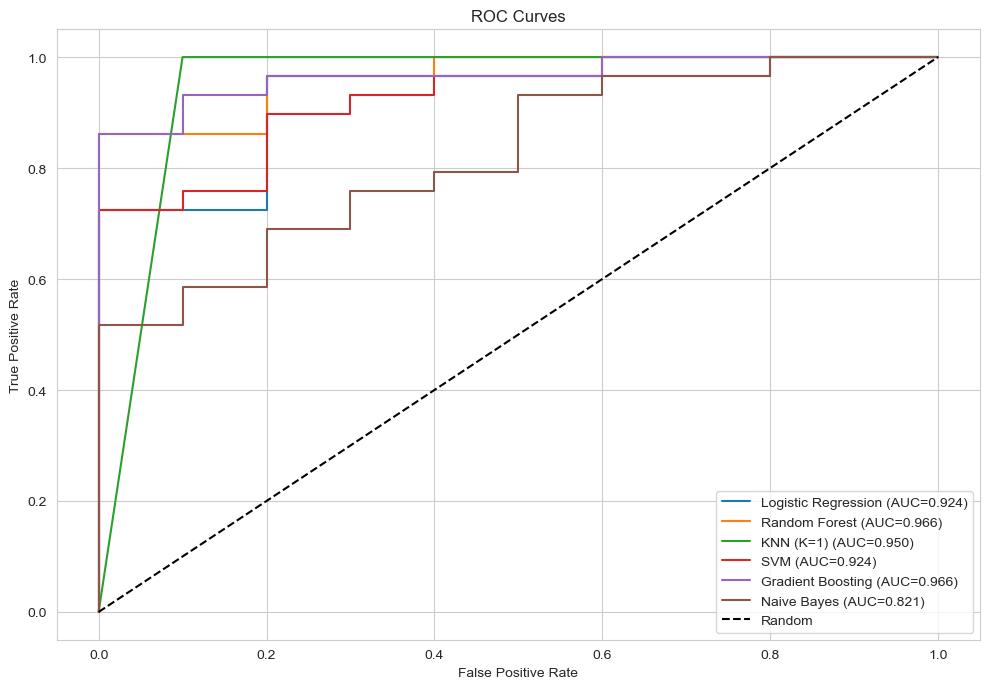

In [23]:
models_for_roc = {
    "Logistic Regression": lr,
    "Random Forest":       rf,
    f"KNN (K={best_k})":   knn,
    "SVM":                 svm,
    "Gradient Boosting":   gb,
    "Naive Bayes":         nb,
}

plt.figure(figsize=(10, 7))
for name, m in models_for_roc.items():
    X_in = X_test_s if name in {"Logistic Regression", f"KNN (K={best_k})", "SVM"} else X_test
    if hasattr(m, "predict_proba"):
        y_prob = m.predict_proba(X_in)[:, 1]
    else:
        y_prob = m.decision_function(X_in)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(loc="lower right")
plt.tight_layout(); plt.show()

# 14. Hyperparameter Tuning - Random Forest

In [27]:
param_gird = {
    "n_estimators"      : [100, 300, 500],
    "max_depth"         : [None, 5, 10],
    "min_samples_split" : [2, 5, 10],
    "min_samples_leaf"  : [1, 2, 4],
}
grid = GridSearchCV(
    RandomForestClassifier(random_state = 42, class_weight = "balanced"),
    param_gird, cv = 5, scoring = "f1", n_jobs = -1)
grid.fit(X_train, y_train)
print(f"Best Params :  {grid.best_params_}")
print(f"Best CV F1  : {grid.best_score_:.4f}")

Best Params :  {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best CV F1  : 0.9247



Random Forest (Tuned)
Accuracy    : 0.9231
Precision   : 0.9333
Recall      : 0.9655
F1 Score    : 0.9492


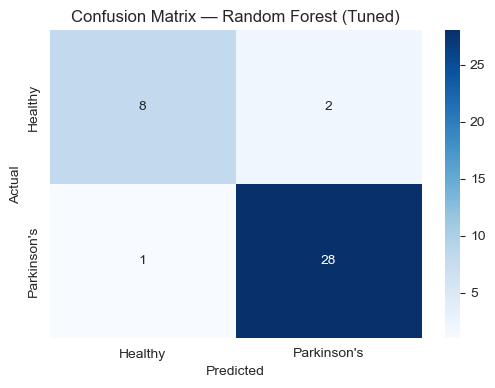

In [28]:
rf_tuned = grid.best_estimator_
pred_rf_t = rf_tuned.predict(X_test)
m_rf_t = evaluate_model("Random Forest (Tuned)", y_test, pred_rf_t)
plot_confusion_matrix(y_test, pred_rf_t, "Random Forest (Tuned)");
plt.show()

# 15. Tuned Feature Importance

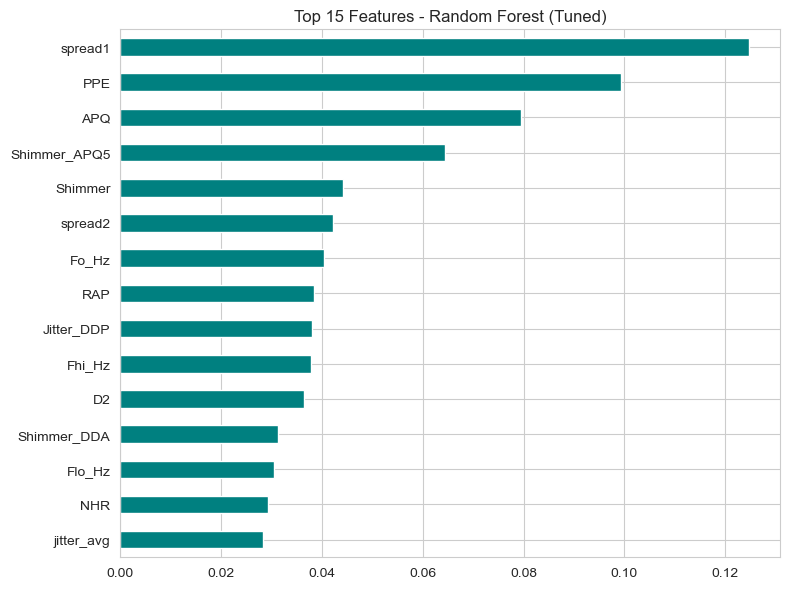

In [32]:
imp = pd.Series(rf_tuned.feature_importances_, index = X.columns).sort_values()
plt.figure(figsize = (8, 6))
imp.tail(15).plot(kind = "barh", color = "teal")
plt.title("Top 15 Features - Random Forest (Tuned)")
plt.tight_layout();
plt.show()

# 16. Prediction Example

In [38]:
sample = X_test.iloc[[0, 1, 2]]
preds = rf_tuned.predict(sample)
probs = rf_tuned.predict_proba(sample)[:, 1]
for i, (idx, _) in enumerate(sample.iterrows()):
    actual = "Parkinson's" if y_test.loc[idx] else "Healthy"
    pred   = "Parkinson's" if preds[i] else "Healthy"
    print(f"Sample {i}: actual={actual:12s}  predicted={pred:12s}  P(PD)={probs[i]:.3f}")

Sample 0: actual=Healthy       predicted=Parkinson's   P(PD)=0.652
Sample 1: actual=Parkinson's   predicted=Parkinson's   P(PD)=0.854
Sample 2: actual=Parkinson's   predicted=Parkinson's   P(PD)=0.986
